# Landsat LST Collection — Rome

This notebook collects Land Surface Temperature (LST) from Landsat 8/9 over Rome
and exports it as a **GeoTIFF pinned to the same 30 m grid as the Sentinel-1 export**.

## Key design decisions vs the original script

| Original script | This notebook |
|---|---|
| `.sample()` → random point locations | `Export.image.toDrive` → regular raster grid |
| No `crsTransform` → grid offset | `crsTransform=[30,0,279750,0,-30,4653180]` → aligned to S1 |
| CSV with lon/lat from `pixelLonLat` | GeoTIFF read with rasterio → exact UTM pixel centres |

**Result:** LST pixel coordinates will match S1 and S2 exactly, so the three-way merge is a simple `pd.merge` on `x_utm` / `y_utm`.

## Setup
```bash
pip install earthengine-api rasterio numpy pandas matplotlib
```

## 1. Authenticate and initialise

In [1]:
import importlib
import subprocess
import sys

# Auto-install earthengine-api if missing (from original script)
try:
    import ee
except ImportError:
    print("Installing earthengine-api...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "earthengine-api"])
    import ee

# First run: uncomment ee.Authenticate()
# ee.Authenticate()

PROJECT_ID = 'first-test-project-492808'   # <-- your GCP project id

try:
    ee.Initialize(project=PROJECT_ID)
except Exception as exc:
    msg = str(exc)
    if 'USER_PROJECT_DENIED' in msg or 'required permission' in msg:
        raise RuntimeError(
            f"Account cannot use project '{PROJECT_ID}'. "
            "Check you have the Service Usage Consumer role."
        ) from exc
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialised.')

Earth Engine initialised.


## 2. Configuration

All parameters in one place. The `CRS_TRANSFORM` is derived from the S1 GeoTIFF
using `rasterio` and must not be changed — it is what pins all three datasets
(S1, S2, LST) to the same pixel grid.

In [2]:
# ── Area of interest ──────────────────────────────────────────────────────────
AOI = ee.Geometry.Rectangle([12.35, 41.78, 12.65, 42.00])

# ── Time window — summer 2025, matches S1 and S2 composites ───────────────────
START_DATE     = '2025-06-01'
END_DATE       = '2025-09-01'
MAX_CLOUD_COVER = 5          # percent — consistent with S2 filter

# ── Grid parameters ───────────────────────────────────────────────────────────
SCALE          = 30
CRS            = 'EPSG:32633'   # UTM Zone 33N

# CRITICAL: crsTransform derived from S1 GeoTIFF via rasterio:
#   with rasterio.open('rome_s1_features_30m_full.tif') as src:
#       print(src.transform.c, src.transform.f)
#   → 279750.0  4653180.0
# Format: [x_scale, 0, x_topleft, 0, y_scale, y_topleft]
CRS_TRANSFORM  = [30, 0, 279750, 0, -30, 4653180]

# ── Export ────────────────────────────────────────────────────────────────────
DRIVE_FOLDER   = 'EarthObservationProject'

print(f'AOI          : Rome bounding box')
print(f'Window       : {START_DATE} → {END_DATE}')
print(f'Max cloud    : {MAX_CLOUD_COVER}%')
print(f'Scale        : {SCALE} m')
print(f'CRS          : {CRS}')
print(f'crsTransform : {CRS_TRANSFORM}')

AOI          : Rome bounding box
Window       : 2025-06-01 → 2025-09-01
Max cloud    : 5%
Scale        : 30 m
CRS          : EPSG:32633
crsTransform : [30, 0, 279750, 0, -30, 4653180]


## 3. Cloud masking

From the original script — masks fill, dilated cloud, cirrus, cloud, cloud shadow,
and snow using the `QA_PIXEL` bitmask from Landsat Collection 2 Level-2.

In [3]:
def mask_landsat_l2_clouds(image):
    """
    Remove invalid pixels, clouds, and shadows using QA_PIXEL.

    QA_PIXEL bit flags (Landsat Collection 2 Level-2):
    Bit 0: fill
    Bit 1: dilated cloud
    Bit 2: cirrus
    Bit 3: cloud
    Bit 4: cloud shadow
    Bit 5: snow
    """
    qa = image.select('QA_PIXEL')
    clear_mask = (
        qa.bitwiseAnd(1 << 0).eq(0)
        .And(qa.bitwiseAnd(1 << 1).eq(0))
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )
    # Also mask pixels where the thermal band itself is invalid (DN = 0)
    st_valid_mask = image.select('ST_B10').gt(0)
    return image.updateMask(clear_mask).updateMask(st_valid_mask)


def add_lst_celsius(image):
    """
    Convert Landsat ST_B10 digital numbers to degrees Celsius.

    Collection 2 Level-2 conversion:
        Kelvin  = DN * 0.00341802 + 149.0
        Celsius = Kelvin - 273.15
    """
    lst_c = (
        image.select('ST_B10')
        .multiply(0.00341802)
        .add(149.0)
        .subtract(273.15)
        .rename('LST_C')
    )
    return image.addBands(lst_c)


print('Cloud masking and LST conversion functions defined.')

Cloud masking and LST conversion functions defined.


## 4. Build the LST composite

Merges Landsat 8 and Landsat 9 for maximum temporal coverage over the summer window.
Takes the **median** across all cloud-free acquisitions — same approach as S1 and S2 composites.

In [4]:
def build_landsat_lst_composite(aoi, start_date, end_date, max_cloud_cover):
    """Build a median LST composite from Landsat 8 + 9 Collection 2 Level-2."""
    landsat_8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    landsat_9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')

    landsat = (
        landsat_8.merge(landsat_9)
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP'))
        .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))
        .map(mask_landsat_l2_clouds)
        .map(add_lst_celsius)
    )

    image_count = landsat.size().getInfo()
    print(f'Landsat images found: {image_count}')

    if image_count == 0:
        raise RuntimeError(
            'No Landsat images found. Try widening the date range '
            'or increasing MAX_CLOUD_COVER.'
        )

    composite = landsat.select(['LST_C', 'ST_QA']).median().clip(aoi)
    print(f'Composite bands: {composite.bandNames().getInfo()}')
    return composite


landsat_lst = build_landsat_lst_composite(
    aoi=AOI,
    start_date=START_DATE,
    end_date=END_DATE,
    max_cloud_cover=MAX_CLOUD_COVER
)

Landsat images found: 11
Composite bands: ['LST_C', 'ST_QA']


## 5. Quick visual check

In [5]:
import geemap

Map = geemap.Map()
Map.centerObject(AOI, 11)

Map.addLayer(
    landsat_lst.select('LST_C'),
    {
        'min': 20, 'max': 50,
        'palette': ['#313695', '#4575b4', '#74add1', '#abd9e9',
                    '#ffffbf', '#fdae61', '#f46d43', '#d73027', '#a50026']
    },
    'LST (°C) — blue=cool, red=hot'
)

Map

Map(center=[41.89003445667141, 12.500000000001013], controls=(WidgetControl(options=['position', 'transparent_…

## 6. Export as GeoTIFF — aligned to S1 grid

This is the **critical fix** vs the original script.

The original used `.sample()` which places points at arbitrary locations → grid mismatch
with S1 and S2 → zero rows on merge.

Here we use `Export.image.toDrive` with the **exact same `crsTransform`** as the S1 export.
This guarantees every LST pixel centre falls at the same coordinate as the corresponding
S1 and S2 pixel.

In [6]:
# Prepare the LST image — single band, cast to Float32
projection = ee.Projection(CRS).atScale(SCALE)

lst_export = (
    landsat_lst
    .select('LST_C')
    .rename('LST')
    .reproject(projection)   # pin to the target projection before export
    .toFloat()               # Float32 — consistent with S1 and S2
)

task = ee.batch.Export.image.toDrive(
    image=lst_export,
    description='Landsat_Roma_LST_30m_aligned',
    folder=DRIVE_FOLDER,
    fileNamePrefix='landsat_roma_lst_30m_aligned',
    scale=SCALE,
    crs=CRS,
    crsTransform=CRS_TRANSFORM,   # same origin as S1 → pixel-perfect alignment
    region=AOI,
    maxPixels=1e9,
    fileFormat='GeoTIFF'
)

task.start()
print(f'Export task started: {task.id}')
print('Monitor at: https://code.earthengine.google.com/tasks')
print(f'Output folder: Google Drive → {DRIVE_FOLDER}')

Export task started: KE2LJJSYCBPDALU3KIJHIK3Y
Monitor at: https://code.earthengine.google.com/tasks
Output folder: Google Drive → EarthObservationProject


## 7. Read GeoTIFF locally after download

Run this cell after downloading `landsat_roma_lst_30m_aligned.tif` from Google Drive.

In [7]:
import rasterio
import numpy as np
import pandas as pd

LST_TIF_PATH = 'landsat_roma_lst_30m_aligned.tif'  # adjust path if needed

with rasterio.open(LST_TIF_PATH) as src:
    data   = src.read(1)      # single band
    nodata = src.nodata
    print(f'CRS       : {src.crs}')
    print(f'Transform : {src.transform}')
    print(f'Shape     : {src.height} rows × {src.width} cols')
    print(f'NoData    : {nodata}')

    rows_idx, cols_idx = np.meshgrid(
        np.arange(src.height), np.arange(src.width), indexing='ij'
    )
    xs, ys = rasterio.transform.xy(
        src.transform, rows_idx.ravel(), cols_idx.ravel()
    )

lst_df = pd.DataFrame({
    'LST'  : data.ravel(),
    'x_utm': xs,
    'y_utm': ys
})

# Drop nodata pixels
if nodata is not None:
    lst_df = lst_df[lst_df['LST'] != nodata]
lst_df = lst_df.dropna().reset_index(drop=True)

print(f'\nLST pixels: {len(lst_df):,}')
print(f'LST range  : {lst_df["LST"].min():.1f} → {lst_df["LST"].max():.1f} °C')
lst_df.head()

CRS       : EPSG:32633
Transform : | 30.00, 0.00, 279750.00|
| 0.00,-30.00, 4653180.00|
| 0.00, 0.00, 1.00|
Shape     : 839 rows × 855 cols
NoData    : None

LST pixels: 677,735
LST range  : 31.5 → 58.6 °C


,LST,x_utm,y_utm
0,48.203659,280515.0,4653165.0
1,47.978069,280545.0,4653165.0
2,47.728554,280575.0,4653165.0
3,47.314972,280605.0,4653165.0
4,46.870632,280635.0,4653165.0


## 8. Verify grid alignment with S1

Before merging, confirm the first few x and y values match exactly.
If they don't match here, the merge will give 0 rows.

In [8]:
# Load S1 for comparison (adjust path as needed)
s1_df = pd.read_csv('rome_s1_features.csv')   # your S1 pixel CSV

print('S1  x (first 4):', sorted(s1_df['x_utm'].unique())[:4])
print('LST x (first 4):', sorted(lst_df['x_utm'].unique())[:4])
print()
print('S1  y (first 4):', sorted(s1_df['y_utm'].unique())[:4])
print('LST y (first 4):', sorted(lst_df['y_utm'].unique())[:4])

# Both rows must be identical — e.g.
# S1  x: [279765.0, 279795.0, 279825.0, 279855.0]
# LST x: [279765.0, 279795.0, 279825.0, 279855.0]

S1  x (first 4): [np.float64(279765.0), np.float64(279795.0), np.float64(279825.0), np.float64(279855.0)]
LST x (first 4): [np.float64(279765.0), np.float64(279795.0), np.float64(279825.0), np.float64(279855.0)]

S1  y (first 4): [np.float64(4628025.0), np.float64(4628055.0), np.float64(4628085.0), np.float64(4628115.0)]
LST y (first 4): [np.float64(4628025.0), np.float64(4628055.0), np.float64(4628085.0), np.float64(4628115.0)]


## 9. LST distribution sanity check

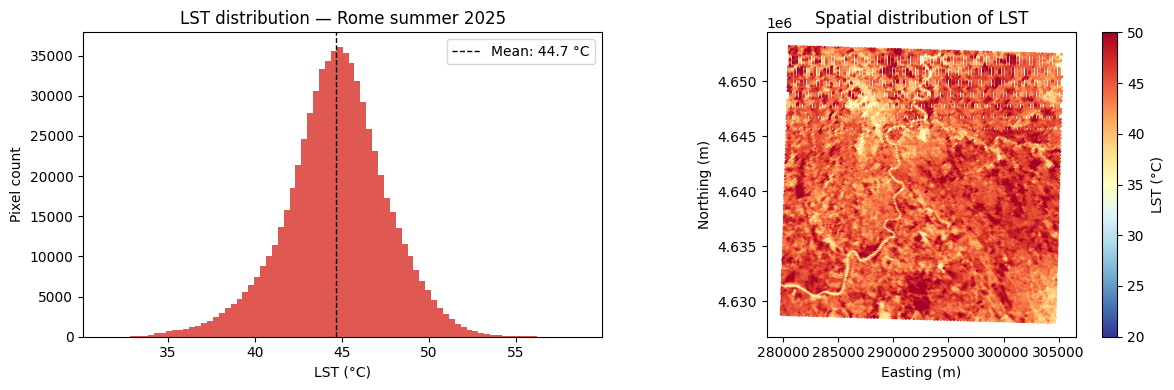

Saved: lst_sanity_check.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(lst_df['LST'], bins=80, color='#d73027', alpha=0.8, edgecolor='none')
axes[0].axvline(lst_df['LST'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'Mean: {lst_df["LST"].mean():.1f} °C')
axes[0].set_xlabel('LST (°C)')
axes[0].set_ylabel('Pixel count')
axes[0].set_title('LST distribution — Rome summer 2025')
axes[0].legend()

# Spatial scatter (every 10th pixel for speed)
step = 10
sc = axes[1].scatter(
    lst_df['x_utm'].iloc[::step],
    lst_df['y_utm'].iloc[::step],
    c=lst_df['LST'].iloc[::step],
    cmap='RdYlBu_r', s=0.5, vmin=20, vmax=50
)
plt.colorbar(sc, ax=axes[1], label='LST (°C)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].set_title('Spatial distribution of LST')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('lst_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lst_sanity_check.png')

In [10]:
# save LST DataFrame for later use
lst_df.to_csv('rome_final_landsat.csv', index=False)
print('Saved: rome_final_landsat.csv')

Saved: rome_final_landsat.csv


## 10. Three-way merge — S1 + S2 + LST

Once all three datasets are aligned on the same `crsTransform` grid,
the merge is a simple exact join on `x_utm` / `y_utm`.

**Expected output:** ~677k rows × (9 S1 + 11 S2 + 1 LST + 2 coords) = ~23 columns

In [ ]:
# # Load all three datasets (adjust paths as needed)
# s1_df  = pd.read_csv('rome_s1_features.csv')
# s2_df  = pd.read_csv('s2_roma_pixel_dataset_final.csv')  # teammate's re-export
# # lst_df already loaded above

# # Merge S1 + S2
# merged = s1_df.merge(s2_df, on=['x_utm', 'y_utm'], how='inner')
# print(f'After S1 + S2 merge: {len(merged):,} rows')

# # Merge with LST
# merged = merged.merge(lst_df, on=['x_utm', 'y_utm'], how='inner')
# print(f'After + LST merge  : {len(merged):,} rows')
# print(f'Total columns      : {merged.shape[1]}')
# print(f'\nColumns: {merged.columns.tolist()}')

# # Quick check — LST should be the target variable, never NaN
# print(f'\nLST NaN count: {merged["LST"].isna().sum()}')
# print(merged.describe().round(3))

In [ ]:
# # Save the final modelling dataset
# output_path = 'rome_uhi_modelling_dataset.csv'
# merged.to_csv(output_path, index=False)
# print(f'Saved: {output_path}')
# print(f'Shape: {merged.shape}')
# merged.head()

## Appendix — original patch export (preserved from original script)

The original script also supported exporting 30×30 pixel LST patches
(useful for CNN-based approaches). This functionality is preserved here
but is **not needed** for the XGBoost + SHAP pipeline.

Uncomment and run if you need patch data for a different model.

In [ ]:
# from typing import Optional

# def build_lst_patch_image(image, patch_size, scale, crs, non_overlapping):
#     """
#     Build a patch image where each pixel contains its full neighbourhood
#     as flattened bands: r00_c00 ... r29_c29 (for patch_size=30).
#     Each row in the exported CSV corresponds to one patch centre pixel
#     and contains 900 LST values + 900 lon values + 900 lat values.
#     """
#     if patch_size < 2:
#         raise ValueError('patch_size must be at least 2.')
#
#     projection = ee.Projection(crs).atScale(scale)
#     anchor = patch_size // 2 if patch_size % 2 else (patch_size // 2) - 1
#     weights = [[1]*patch_size for _ in range(patch_size)]
#     kernel = ee.Kernel.fixed(
#         width=patch_size, height=patch_size,
#         weights=weights, x=anchor, y=anchor, normalize=False
#     )
#     lst = image.select('LST_C').reproject(projection)
#     st_qa = image.select('ST_QA').reproject(projection).rename('ST_QA_center')
#     lonlat = ee.Image.pixelLonLat().reproject(projection)
#     lon = lonlat.select('longitude')
#     lat = lonlat.select('latitude')
#     valid_count = lst.mask().unmask(0).reduceNeighborhood(
#         reducer=ee.Reducer.sum(), kernel=kernel
#     )
#     complete_patch_mask = valid_count.eq(patch_size * patch_size)
#     row_labels = [f'r{i:02d}' for i in range(patch_size)]
#     col_labels = [f'c{i:02d}' for i in range(patch_size)]
#     patch_flat = (
#         lst.neighborhoodToArray(kernel)
#         .arrayFlatten([row_labels, col_labels])
#         .updateMask(complete_patch_mask)
#     )
#     flat_names = [f'{r}_{c}' for r in row_labels for c in col_labels]
#     lon_flat = (
#         lon.neighborhoodToArray(kernel)
#         .arrayFlatten([row_labels, col_labels])
#         .rename([f'lon_{n}' for n in flat_names])
#         .updateMask(complete_patch_mask)
#     )
#     lat_flat = (
#         lat.neighborhoodToArray(kernel)
#         .arrayFlatten([row_labels, col_labels])
#         .rename([f'lat_{n}' for n in flat_names])
#         .updateMask(complete_patch_mask)
#     )
#     patch_image = (
#         patch_flat.addBands(lon_flat).addBands(lat_flat)
#         .addBands(lst.rename('LST_C_center'))
#         .addBands(lon.rename('lon_center'))
#         .addBands(lat.rename('lat_center'))
#         .addBands(st_qa)
#     )
#     if non_overlapping:
#         coords = ee.Image.pixelCoordinates(projection)
#         anchor_coord = anchor + 0.5
#         stride_mask = (
#             coords.select('x').mod(patch_size).eq(anchor_coord)
#             .And(coords.select('y').mod(patch_size).eq(anchor_coord))
#         )
#         patch_image = patch_image.updateMask(stride_mask)
#     return patch_image
#
# PATCH_SIZE = 30
# patch_img = build_lst_patch_image(
#     image=landsat_lst, patch_size=PATCH_SIZE,
#     scale=SCALE, crs=CRS, non_overlapping=True
# )
# patch_data = patch_img.sample(
#     region=AOI, scale=SCALE, projection=CRS,
#     geometries=True, dropNulls=True
# )
# patch_task = ee.batch.Export.table.toDrive(
#     collection=patch_data,
#     description='Landsat_Roma_LST_30x30_Patches',
#     folder=DRIVE_FOLDER,
#     fileNamePrefix='landsat_roma_lst_patches',
#     fileFormat='CSV'
# )
# patch_task.start()
# print(f'Patch export started: {patch_task.id}')